In [23]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [38]:
df_clean = pd.read_csv('../data/data_clean.csv')
df_clean = df_clean.rename(columns={'against_psychict': 'against_psychic'})
print(df_clean.columns)
df_labels = df_clean.copy()[['class_primary','class_secondary','attack']]
df_names = df_clean['english_name']
df_data = df_clean.drop(columns=['english_name','class_primary','class_secondary','attack'])

Index(['gen', 'english_name', 'percent_male', 'percent_female', 'height_m',
       'weight_kg', 'capture_rate', 'base_egg_steps', 'hp', 'attack',
       'defense', 'sp_attack', 'sp_defense', 'speed', 'against_normal',
       'against_fire', 'against_water', 'against_electric', 'against_grass',
       'against_ice', 'against_fighting', 'against_poison', 'against_ground',
       'against_flying', 'against_psychic', 'against_bug', 'against_rock',
       'against_ghost', 'against_dragon', 'against_dark', 'against_steel',
       'against_fairy', 'votes_first', 'votes_top_6', 'num_abilities',
       'evo_length', 'has_mega_evolution', 'has_gigantamax', 'rarity',
       'class_primary', 'class_secondary'],
      dtype='object')


In [26]:
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist, squareform

X= df_mk.copy()

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Compute distance matrix (Euclidean)
dist = pdist(X_std, metric='euclidean')
dist_matrix = DistanceMatrix(squareform(dist))

# Grouping by generation
grouping = df_clean['gen'].astype(int).reset_index(drop=True)

# Make sure grouping index matches distance matrix IDs
dist_matrix.ids = grouping.index.astype(str).tolist()

# Run PERMANOVA
permanova_res = permanova(dist_matrix, grouping.tolist(), permutations=100)
print(permanova_res)
permanova_res = permanova(dist_matrix, grouping.tolist(), permutations=1000)
print(permanova_res)
permanova_res = permanova(dist_matrix, grouping.tolist(), permutations=10000)
print(permanova_res)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1024
number of groups                  9
test statistic             3.542946
p-value                    0.009901
number of permutations          100
Name: PERMANOVA results, dtype: object
method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1024
number of groups                  9
test statistic             3.542946
p-value                    0.000999
number of permutations         1000
Name: PERMANOVA results, dtype: object
method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1024
number of groups                  9
test statistic             3.542946
p-value                      0.0001
number of permutations        10000
Name: PERMANOVA results, dtype: object


In [27]:
from sklearn.linear_model import LinearRegression

def multivar_r2(Y, X):
    model = LinearRegression().fit(X, Y)
    Y_hat = model.predict(X)
    ss_res = np.sum((Y - Y_hat)**2)
    ss_tot = np.sum((Y - Y.mean(axis=0))**2)
    return 1 - ss_res/ss_tot

# Select relevant features for X
features = ['attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'hp', 'num_abilities']
X = df_clean[features].values

# Standardize X
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print("Standardized feature means (should be ~0):", X_std.mean(axis=0))

# Predictor (numeric generations, centered)
g = df_clean['gen'].values.astype(float).reshape(-1,1)
g = g - g.mean()

Y = X_std  # standardized data matrix

# observed R²
obs_r2 = multivar_r2(Y, g)

# permutation test
n_perm = 1999
perm_r2 = np.zeros(n_perm)
for i in range(n_perm):
    perm = np.random.permutation(g)
    perm_r2[i] = multivar_r2(Y, perm)

p_value = (np.sum(perm_r2 >= obs_r2) + 1) / (n_perm + 1)

print("Observed multivariate R² vs generation:", obs_r2)
print("Permutation p-value (trend):", p_value)

""" - It defines a function `multivar_r2` to compute the multivariate R² (proportion of variance in all stats explained by generation).
- The predictor `g` is the generation number, centered to mean zero.
- It calculates the observed R² between standardized stats and generation.
- Then, it runs a permutation test: it randomly shuffles the generation labels many times (`n_perm`), recalculates R² for each shuffle, and compares the observed R² to this null distribution.
- The p-value tells you how likely it is to see an R² as large as observed, if there were no real trend.

If the p-value is small, it suggests a significant trend in stats across generations. """

pass


Standardized feature means (should be ~0): [1.38777878e-17 6.93889390e-18 6.93889390e-18 0.00000000e+00
 0.00000000e+00 0.00000000e+00 5.55111512e-17]
Observed multivariate R² vs generation: 0.014577082657605489
Permutation p-value (trend): 0.0005


In [28]:
# Primary type id -> type name
PRIMARY_ID_TO_TYPE = {
    0: "grass", 1: "fire", 2: "water", 3: "bug", 4: "normal",
    5: "poison", 6: "electric", 7: "ground", 8: "fairy",
    9: "fighting", 10: "psychic", 11: "rock", 12: "ghost",
    13: "ice", 14: "dragon", 15: "dark", 16: "steel", 17: "flying"
}

# Secondary type id -> type name
SECONDARY_ID_TO_TYPE = {
    0: "poison", 1: None, 2: "flying", 3: "dark", 4: "electric",
    5: "ice", 6: "ground", 7: "fairy", 8: "grass", 9: "fighting",
    10: "psychic", 11: "steel", 12: "fire", 13: "rock",
    14: "water", 15: "dragon", 16: "ghost", 17: "bug", 18: "normal"
}

# Reverse lookup: type name -> primary type id (for merged_primary_class)
TYPE_TO_MERGED_PRIMARY_ID = {v: k for k, v in PRIMARY_ID_TO_TYPE.items()}
# Create a new DataFrame where Pokémon with both primary and secondary types are split into two rows,
# one for each type as "merged_primary_class". All stats are duplicated except for the type column.
rows = []
for idx, row in df_clean.iterrows():
    primary = row['class_primary']
    secondary = row['class_secondary']
    name = row['english_name']
    # Always add the primary type row
    row_primary = row.copy()
    row_primary['merged_primary_class'] = primary
    rows.append(row_primary)
    # If secondary type is not None (not 1), add a row for the secondary type as well
    if secondary != 1:
        # Find the primary mapping number for the secondary type name
        sec_type_name = SECONDARY_ID_TO_TYPE[secondary]
        # Find the primary id for this type name
        sec_type_id_in_primary = TYPE_TO_MERGED_PRIMARY_ID.get(sec_type_name, None)
        if sec_type_id_in_primary is not None:
            row_secondary = row.copy()
            row_secondary['merged_primary_class'] = sec_type_id_in_primary
            row_secondary['english_name'] = f"{name}"
            rows.append(row_secondary)

df_merged = pd.DataFrame(rows)

# Build mapping dict for merged_primary_class (only primary type ids)
MERGED_PRIMARY_ID_TO_TYPE = PRIMARY_ID_TO_TYPE.copy()
df_merged = df_merged.drop(columns=['class_primary', 'class_secondary'])

print(df_merged.shape)
df_merged.columns

(1577, 40)


Index(['gen', 'english_name', 'percent_male', 'percent_female', 'height_m',
       'weight_kg', 'capture_rate', 'base_egg_steps', 'hp', 'attack',
       'defense', 'sp_attack', 'sp_defense', 'speed', 'against_normal',
       'against_fire', 'against_water', 'against_electric', 'against_grass',
       'against_ice', 'against_fighting', 'against_poison', 'against_ground',
       'against_flying', 'against_psychic', 'against_bug', 'against_rock',
       'against_ghost', 'against_dragon', 'against_dark', 'against_steel',
       'against_fairy', 'votes_first', 'votes_top_6', 'num_abilities',
       'evo_length', 'has_mega_evolution', 'has_gigantamax', 'rarity',
       'merged_primary_class'],
      dtype='object')

In [29]:

import numpy as np

def pokemon_win_rate_sequential(df):
    """
    Returns:
        win_rate: ndarray of shape (N,)
            win_rate[i] = fraction of Pokémon i beats
    """

    # ---------------------------
    # Extract stats
    # ---------------------------
    atk    = df["attack"].to_numpy()
    sp_atk = df["sp_attack"].to_numpy()
    defn   = df["defense"].to_numpy()
    sp_def = df["sp_defense"].to_numpy()
    hp     = df["hp"].to_numpy()
    speed  = df["speed"].to_numpy()
    types  = df["merged_primary_class"].to_numpy()

    N = len(df)

    # ---------------------------
    # Type effectiveness table
    # ---------------------------
    TYPES = [
        "grass","fire","water","bug","normal","poison","electric","ground",
        "fairy","fighting","psychic","rock","ghost","ice","dragon","dark",
        "steel","flying"
    ]

    # (N defender, 18)
    against = np.stack(
        [df[f"against_{t}"].to_numpy() for t in TYPES],
        axis=1
    )

    win_count = np.zeros(N, dtype=np.int32)

    # ---------------------------
    # Sequential comparison
    # ---------------------------
    for i in range(N):
        # Damage i -> all
        physical_i = atk[i] / np.maximum(defn, 1)
        special_i  = sp_atk[i] / np.maximum(sp_def, 1)

        base_i = 0.5 * physical_i + 0.5 * special_i

        type_eff_i = against[:, types[i]]

        dmg_i = base_i * type_eff_i * 1.5
        norm_i = dmg_i / hp

        # Damage all -> i
        physical_j = atk / max(defn[i], 1)
        special_j  = sp_atk / max(sp_def[i], 1)

        base_j = 0.5 * physical_j + 0.5 * special_j

        type_eff_j = against[i, types]

        dmg_j = base_j * type_eff_j * 1.5
        norm_j = dmg_j / hp[i]

        # Compare
        win = norm_i > norm_j
        tie = np.isclose(norm_i, norm_j)
        speed_win = speed[i] > speed

        win_count[i] += np.sum(win | (tie & speed_win))

    return win_count 




In [30]:
win_counts = pokemon_win_rate_sequential(df_merged)

leaderboard = pd.DataFrame({
    'Name': df_merged['english_name'],
    'Wins': win_counts,
    'gen': df_merged['gen'],
    'type': df_merged['merged_primary_class'],
    'rarity': df_merged['rarity']
})

In [31]:

leaderboard = (
    leaderboard
    .groupby('Name', as_index=False)
    .agg(
        Wins=('Wins', 'mean'),
        gen=('gen', 'first'),
        rarity=('rarity', 'first') 
    )
    .sort_values(by='Wins', ascending=False)
    .reset_index(drop=True)
)
leaderboard
print(leaderboard.head(10))  # Show top 10

        Name    Wins  gen  rarity
0    Xerneas  1484.0  6.0     2.0
1    Yveltal  1480.0  6.0     2.0
2     Arceus  1473.0  4.0     3.0
3     Dialga  1464.0  4.0     2.0
4    Slaking  1445.0  3.0     0.0
5   Solgaleo  1443.5  7.0     2.0
6     Palkia  1431.0  4.0     2.0
7  Regigigas  1427.0  4.0     1.0
8   Giratina  1426.5  4.0     2.0
9   Melmetal  1423.0  7.0     0.0


           mean  median
gen                    
1.0  594.225166   626.0
2.0  557.750000   541.0
3.0  581.200000   592.0
4.0  472.906542   457.0
5.0  505.397436   509.0
6.0  491.263889   541.0
7.0  449.590909   421.5
8.0  473.221053   431.0
9.0  427.116667   379.5


C:\Users\jenda\AppData\Local\Temp\ipykernel_19472\3202652227.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gen', y='Rank', data=leaderboard, palette=palette, showfliers=False)


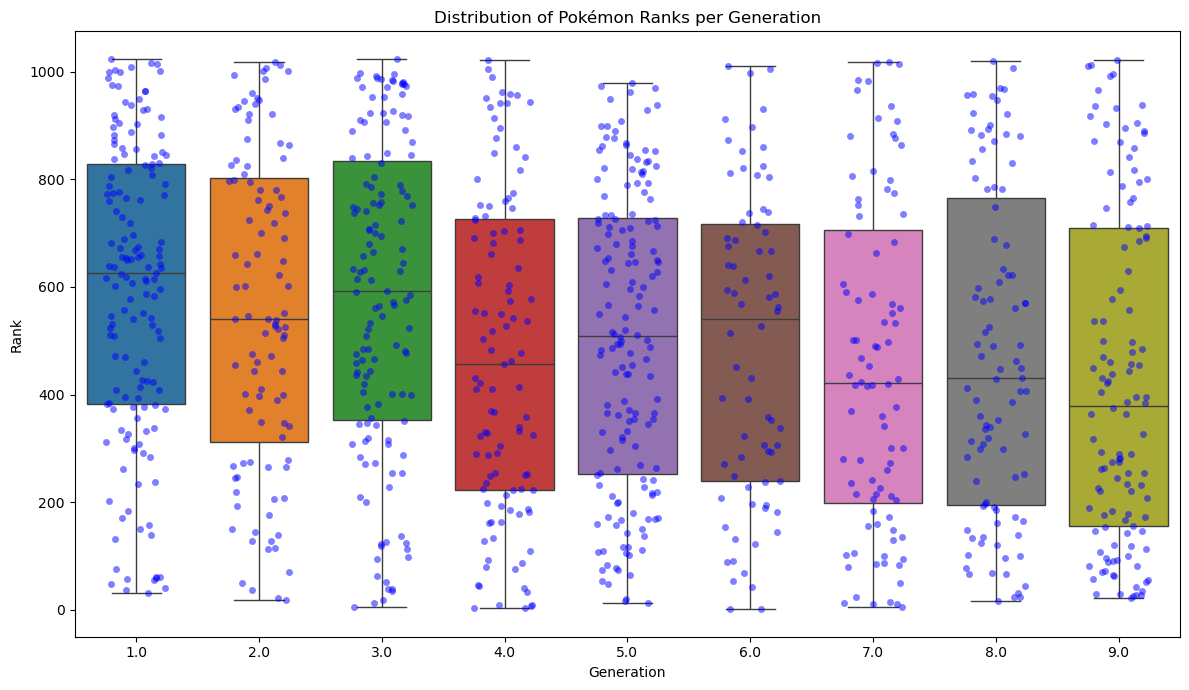


Top 10 Pokémon in the leaderboard:
        Name    Wins  Rank  gen
0    Xerneas  1484.0   1.0  6.0
1    Yveltal  1480.0   2.0  6.0
2     Arceus  1473.0   3.0  4.0
3     Dialga  1464.0   4.0  4.0
4    Slaking  1445.0   5.0  3.0
5   Solgaleo  1443.5   6.0  7.0
6     Palkia  1431.0   7.0  4.0
7  Regigigas  1427.0   8.0  4.0
8   Giratina  1426.5   9.0  4.0
9   Melmetal  1423.0  10.0  7.0


In [32]:

# Compute rank (1 = highest wins, so highest wins get rank 1)
leaderboard['Rank'] = leaderboard['Wins'].rank(ascending=False, method='min')

# Group by generation and calculate average and median rank
gen_rank_stats = leaderboard.groupby('gen')['Rank'].agg(['mean', 'median'])
print(gen_rank_stats)

plt.figure(figsize=(12, 7))
palette = sns.color_palette("tab10", n_colors=leaderboard['gen'].nunique())

# Boxplot with colored generations
sns.boxplot(x='gen', y='Rank', data=leaderboard, palette=palette, showfliers=False)

# Overlay scatter (stripplot) for each Pokémon, colored by generation
sns.stripplot(x='gen', y='Rank', data=leaderboard, color='b', dodge=True, alpha=0.5, jitter=0.25, marker='o')

plt.title('Distribution of Pokémon Ranks per Generation')
plt.xlabel('Generation')
plt.ylabel('Rank')
plt.tight_layout()
plt.show()

print("\nTop 10 Pokémon in the leaderboard:")
print(leaderboard.head(10)[['Name', 'Wins', 'Rank', 'gen']])

In [33]:
import numpy as np
from scipy.stats import norm

def jt_test(gen, rank):
    gen = np.asarray(gen)
    rank = np.asarray(rank)

    groups = [rank[gen == g] for g in np.unique(gen)]

    # JT statistic
    J = sum(
        np.sum(a[:, None] > b[None, :]) + 0.5*np.sum(a[:, None] == b[None, :])
        for i, a in enumerate(groups[:-1])
        for b in groups[i+1:]
    )

    n = sum(len(g) for g in groups)
    n_i = np.array([len(g) for g in groups])

    mean_J = (n**2 - np.sum(n_i**2)) / 4
    var_J = (n*(n-1)*(2*n+5) - np.sum(n_i*(n_i-1)*(2*n_i+5))) / 72

    z = (J - mean_J) / np.sqrt(var_J)
    p = 1 - norm.cdf(z)   # one-sided: later gens better ranks

    return z, p

z, p = jt_test(leaderboard["gen"], leaderboard["Rank"])
print(f"JT test: z = {z:.5f}, p = {p}")


from scipy.stats import kendalltau

tau, tau_p = kendalltau(leaderboard["gen"], leaderboard["Rank"])
print(f"Kendall tau = {tau:.5f}, p = {tau_p:.10g}")


JT test: z = 5.78960, p = 3.5277403220845827e-09
Kendall tau = -0.12763, p = 7.055223447e-09
